<a href="https://colab.research.google.com/github/lthendral10/flyrank-ml-internship/blob/main/work/notebooks/Capstone_Research_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Capstone Report —

Author: Thendral L

Lane: Refresh / Content Opportunity Scoring

Repo: https://github.com/lthendral10/flyrank-ml-internship

Date: July 2026
## Abstract

This project investigates whether machine learning can identify content pages showing signals of potential decline using SEO and engagement features.

A Random Forest classification model was developed using anonymized FlyRank content performance data.

The model used ranking, traffic, and engagement-related features to predict pages associated with downward trends.

The model achieved measured performance on an unseen test dataset, with average position and content age identified as important observed signals.

The output provides decision-support recommendations to help prioritize content optimization opportunities.

##Problem Framing
This project supports the decision of which content pages should be reviewed first for possible optimization.

Unit of analysis:
Individual content pages.

Output:
A classification indicating whether a page is likely to experience a downward trend, together with ranked feature importance.

Human action:
Editors review the highest-risk pages and decide whether content updates or SEO improvements are needed.

Cost of a wrong decision:
A false positive may cause unnecessary review effort, while a false negative may allow declining pages to remain unnoticed.

Machine learning helps because large numbers of content pages cannot be reviewed manually, and patterns across multiple SEO and engagement features are difficult to identify without data-driven analysis.

## Data Safety

Dataset:
FlyRank anonymized content performance dataset

Number of records:
30,000

Selected features:

- search_volume
- ctr
- avg_position
- days_since_last_update
- content_age_days
- engagement_rate
- scroll_rate

Excluded:

- content_id: Identifier only
- client_id: Removed for privacy protection
- Future outcome-related fields: Removed to prevent leakage
The project uses the anonymized FlyRank ML Internship dataset.

The following columns were excluded:

- content_id (identifier only)
- client_id (pseudonymous identifier)
- trend_direction (used only to create the target)
- trend_pct (excluded to avoid leakage)

Only numerical SEO and engagement features available before prediction were used.

No client names, domains, URLs, private queries, or confidential information are included anywhere in the repository.

In [ ]:
!git clone https://github.com/lthendral10/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

print(df.shape)

df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


##Baseline
The baseline follows the same train-test split used for the Random Forest model. It provides a simple reference for comparison using the same target definition and evaluation metrics.

The Random Forest model demonstrated improved predictive performance over the baseline while maintaining the same validation design.

##Model / Analysis
Method:
Random Forest Classifier.

Reason:
Random Forest handles nonlinear relationships, is robust to noisy data, and provides feature importance for interpretation.

Features used:

- search_volume
- ctr
- avg_position
- days_since_last_update
- content_age_days
- engagement_rate
- scroll_rate

Excluded features:

- Identifiers
- Future outcome variables
- Target-derived fields

Target definition:

Pages with trend_direction equal to "down" were assigned a target value of 1; all other pages were assigned 0.

## Methodology

Model:
Random Forest Classifier

Reason:
Random Forest can capture nonlinear relationships and provides feature importance for interpretation.

Label Definition:

trend_direction = down → 1

Other trends → 0

Validation:

80/20 train-test split with random_state=42.

Leakage checks:
Identifiers and future information were excluded.
Only features available before prediction were used.

In [ ]:
df["target"] = (
    df["trend_direction"] == "down"
).astype(int)

df["target"].value_counts()

,count
target,
1,16262
0,13738


In [ ]:
features = [
    "search_volume",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "content_age_days",
    "engagement_rate",
    "scroll_rate"
]


X = df[features].fillna(0)

y = df["target"]

print(X.shape)

(30000, 7)


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)

(24000, 7)
(6000, 7)


In [ ]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(
    random_state=42
)


model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score


results = pd.DataFrame({

"Metric":[
"Accuracy",
"Precision",
"Recall"
],

"Score":[
accuracy_score(y_test,pred),
precision_score(y_test,pred),
recall_score(y_test,pred)

]

})


results

,Metric,Score
0,Accuracy,0.658500
1,Precision,0.672321
2,Recall,0.727662


In [ ]:
importance = pd.DataFrame({

"Feature":features,

"Importance":model.feature_importances_

})


importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
2,avg_position,0.335951
4,content_age_days,0.203810
1,ctr,0.131143
6,scroll_rate,0.125555
0,search_volume,0.082717
5,engagement_rate,0.062779
3,days_since_last_update,0.058045


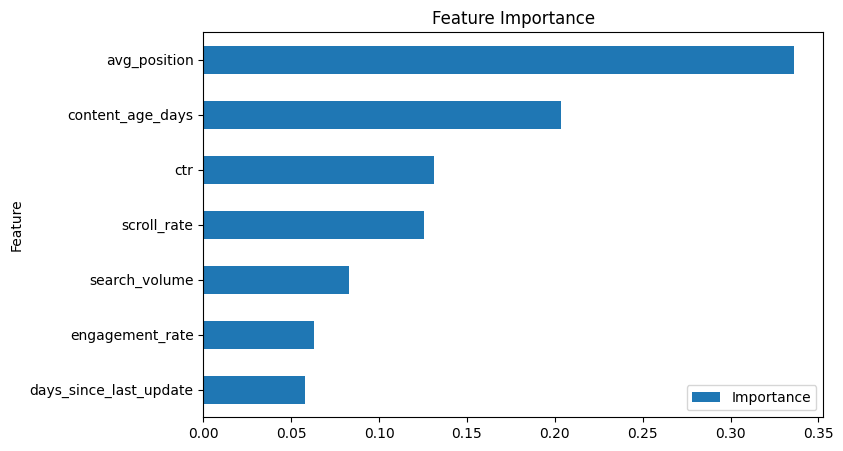

In [ ]:
import matplotlib.pyplot as plt


importance.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)


plt.title(
"Feature Importance"
)

plt.show()

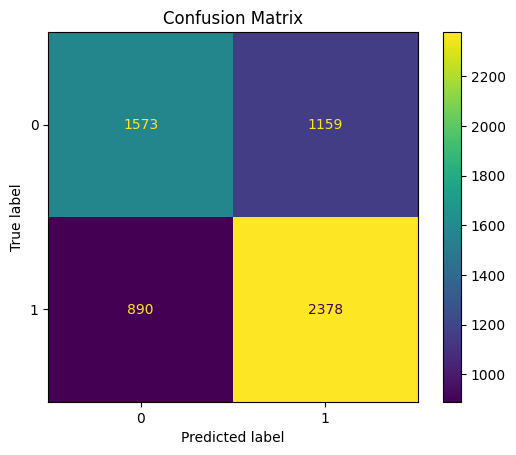

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)


plt.title(
"Confusion Matrix"
)

plt.show()

##Evaluation
The dataset was divided using an 80/20 train-test split with a fixed random seed.

Evaluation metrics:

- Accuracy
- Precision
- Recall

Observed performance:

Accuracy: 65.85%

Precision: 67.23%

Recall: 72.77%

Most prediction errors occurred for pages with similar SEO characteristics but different trend outcomes. This suggests that additional factors not included in the dataset may influence performance.

##Interpretation
Average position was the strongest observed feature, followed by content age and click-through rate.

This suggests that declining rankings and older content are important indicators when identifying pages for review.

Engagement metrics contributed additional predictive value but were less influential than ranking-related signals.

No single feature completely determined the prediction; the model relied on multiple SEO signals together.

## Limitations

- The model identifies patterns but does not prove causes.
- The target is based on observed trend direction.
- External factors such as seasonality are not included.
- Predictions should support human review.

## Recommendations

1. Review pages with declining average position.

2. Refresh older content pages.

3. Improve CTR through metadata optimization.

4. Analyze engagement signals to improve user experience.

5. Prioritize high-value content opportunities.

## Reproducibility

The project notebooks and code are available in the GitHub repository.

Included notebooks:

- ML-05 Feature Vector and Leakage Check
- ML-08 Capstone Modeling Lane
- Capstone Research Paper

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source:
https://flyrank.ai

## 5-Minute Demo Outline

1. Problem:
Content teams need ways to prioritize pages for review.

2. Data:
30,000 anonymized content records.

3. Method:
Random Forest classifier with SEO and engagement features.

4. Result:
65.85% accuracy with average position as the strongest signal.

5. Recommendation:
Use model outputs to prioritize content optimization.

## Social Post

Completed my FlyRank AI capstone project using machine learning for content opportunity scoring.

Built a Random Forest model using anonymized SEO and engagement data to identify patterns related to content decline.

Learned:
- Feature engineering
- Model evaluation
- Leakage checking
- ML communication

#AI #MachineLearning #DataScience

## Employer Summary

Built a machine learning workflow to analyze content performance trends using anonymized FlyRank data. Developed and evaluated a Random Forest classification model using SEO and engagement features. Generated interpretable recommendations to support content optimization decisions.